In [2]:
# ==============================================================================
# BLOQUE 1 - FASE 2: COMPRENSIÓN DE LOS DATOS E INGESTA (ENTORNO COLAB)
# ==============================================================================

# 1. Instalación de librerías esenciales (Ejecutar solo una vez por sesión)
!pip install -q transformers datasets evaluate accelerate scikit-learn

import pandas as pd
import torch
from google.colab import drive

# 2. Conexión con el sistema de archivos de Google Drive
# Solicitará permisos emergentes. Es obligatorio para leer el CSV y luego guardar el modelo.
drive.mount('/content/drive')

print("\n" + "="*60)
# 3. Validación estricta de Hardware (GPU)
# El ajuste fino de un Transformer requiere aceleración por hardware. Sin GPU, el kernel colapsará por falta de RAM.
if torch.cuda.is_available():
    dispositivo = torch.cuda.get_device_name(0)
    print(f"✅ ESTADO DE ENTORNO: GPU detectada correctamente ({dispositivo}).")
else:
    print("❌ CRÍTICO: No se detectó GPU. Vaya a 'Entorno de ejecución' -> 'Cambiar tipo de entorno' y seleccione 'T4 GPU'.")
print("="*60 + "\n")

# 4. Ingesta del conjunto de datos
# REEMPLAZAR 'TU_CARPETA' por el nombre exacto del directorio en Drive
ruta_dataset = '/content/drive/MyDrive/Proyecto_NLP/data_estudiantes.csv'

try:
    # Carga del archivo CSV a la memoria de Pandas y utf-8 por las tíldes y otros
    df = pd.read_csv(ruta_dataset, encoding='utf-8')

    # Saneamiento inicial: Garantizar que la etiqueta predictiva sea de tipo numérico entero (0 o 1)
    # Esto previene errores críticos de desajuste de tipos (Type Mismatch) durante el entrenamiento matemático.
    df['label'] = df['label'].astype(int)

    print("ESTADO DEL DATASET: Archivo cargado exitosamente.\n")
    print(f"Total de registros (filas): {df.shape[0]}")
    print(f"Total de atributos (columnas): {df.shape[1]}\n")

    # 5. Análisis Exploratorio Básico (EDA) - Balance de Clases
    conteo_clases = df['label'].value_counts()
    print("Distribución actual de la variable objetivo (Target):")
    print(conteo_clases)
    print(f"--> {conteo_clases.get(1, 0)} textos catalogados como Estrés (1)")
    print(f"--> {conteo_clases.get(0, 0)} textos catalogados como No Estrés (0)\n")

    print("Muestra de los 3 primeros registros para validación de formato:")
    display(df.head(3))

except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo en la ruta especificada:\n{ruta_dataset}\nVerifique que el nombre de la carpeta y el archivo sean exactos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ ESTADO DE ENTORNO: GPU detectada correctamente (Tesla T4).

ESTADO DEL DATASET: Archivo cargado exitosamente.

Total de registros (filas): 720
Total de atributos (columnas): 3

Distribución actual de la variable objetivo (Target):
label
0    384
1    336
Name: count, dtype: int64
--> 336 textos catalogados como Estrés (1)
--> 384 textos catalogados como No Estrés (0)

Muestra de los 3 primeros registros para validación de formato:


,id,texto,label
0,1,Me gusta bastante la metodología de Ingeniería...,0
1,2,"El nivel del examen parcial estuvo regular, de...",0
2,3,Las clases de hoy sobre Introducción a la Comp...,0


In [3]:
# ==============================================================================
# BLOQUE 2 - FASE 3: PREPARACIÓN DE DATOS (SPLIT TRIPLE Y VECTORIZACIÓN)
# ==============================================================================

from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer

print("\n" + "="*60)
print("INICIANDO FASE 3: SEGMENTACIÓN TRIPLE Y TOKENIZACIÓN")
print("="*60 + "\n")

# 1. División Triple del Conjunto de Datos (Train / Val / Test)
# Paso A: Separamos el 70% para Entrenamiento y el 30% restante para Temp.
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)

# Paso B: Dividimos el 30% temporal en dos mitades iguales (15% Val / 15% Test).
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42, #no es que sea "aleatorio", es parte de la estratificación nada mas(como en orange).
    stratify=df_temp['label'] #o sea un punto de partida para el generador de números aleatorios
)

print("Distribución del Corpus (Triple Bóveda):")
print(f"--> Entrenamiento (70%): {len(df_train)} registros (Actualiza pesos).")
print(f"--> Validación (15%): {len(df_val)} registros (Detecta Overfitting).")
print(f"--> Testeo Ciego (15%): {len(df_test)} registros (Métrica final).\n")

# 2. Conversión al formato nativo de Hugging Face (Dataset)
ds_train = Dataset.from_pandas(df_train)
ds_val = Dataset.from_pandas(df_val)
ds_test = Dataset.from_pandas(df_test)

# 3. Descarga del Tokenizador Especializado
print("Conectando con Hugging Face para descargar el tokenizador BBPE...")
nombre_modelo = "pysentimiento/robertuito-base-cased"
tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)

# 4. Función de Vectorización Optimizada (max_length=96)
def tokenizar_textos(lote):
    """
    Transforma texto en vectores.
    Se reduce max_length a 96 para optimizar tiempo de cómputo y VRAM,
    siendo suficiente para la longitud promedio de comentarios digitales.
    """
    return tokenizer(
        lote["texto"],
        padding="max_length",
        truncation=True,
        max_length=96 #porque tenemos aprox. 10-50 palabras por texto.
    )                 #no pasan de 80 tokens por palabra

# 5. Ejecución del Mapeo Tensorial
print("\nVectorizando conjuntos (Train, Val, Test) a tensores de 96 posiciones...")
ds_train_tokenizado = ds_train.map(tokenizar_textos, batched=True)
ds_val_tokenizado = ds_val.map(tokenizar_textos, batched=True)
ds_test_tokenizado = ds_test.map(tokenizar_textos, batched=True)

# 6. Limpieza Estructural (Remoción de cadenas de texto)
columnas_a_borrar = ["texto", "__index_level_0__"]

# Manejo de error silencioso en caso de que '__index_level_0__' no exista
col_borrar_train = [col for col in columnas_a_borrar if col in ds_train_tokenizado.column_names]

ds_train_tokenizado = ds_train_tokenizado.remove_columns(col_borrar_train)
ds_val_tokenizado = ds_val_tokenizado.remove_columns(col_borrar_train)
ds_test_tokenizado = ds_test_tokenizado.remove_columns(col_borrar_train)

print("\n✅ ESTADO: Fase 3 completada. Datos listos para entrenamiento.")


INICIANDO FASE 3: SEGMENTACIÓN TRIPLE Y TOKENIZACIÓN

Distribución del Corpus (Triple Bóveda):
--> Entrenamiento (70%): 504 registros (Actualiza pesos).
--> Validación (15%): 108 registros (Detecta Overfitting).
--> Testeo Ciego (15%): 108 registros (Métrica final).

Conectando con Hugging Face para descargar el tokenizador BBPE...


config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/319 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/828k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]


Vectorizando conjuntos (Train, Val, Test) a tensores de 96 posiciones...


Map:   0%|          | 0/504 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]


✅ ESTADO: Fase 3 completada. Datos listos para entrenamiento.


In [4]:
# ==============================================================================
# BLOQUE 3 - FASE 4: MODELADO Y AJUSTE FINO (FINE-TUNING)
# ==============================================================================

import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("\n" + "="*60)
print("INICIANDO FASE 4: CONFIGURACIÓN DE ARQUITECTURA Y ENTRENAMIENTO")
print("="*60 + "\n")

# 1. Instanciación de la Arquitectura Base
print("Descargando pesos neuronales y acoplando nueva cabeza clasificadora binaria...")
nombre_modelo = "pysentimiento/robertuito-base-cased"
modelo = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# 2. Definición de las Métricas de Evaluación
metrica_f1 = evaluate.load("f1")
metrica_acc = evaluate.load("accuracy")

def calcular_metricas(eval_pred):
    predicciones, etiquetas = eval_pred
    predicciones_procesadas = np.argmax(predicciones, axis=1)

    resultados_f1 = metrica_f1.compute(predictions=predicciones_procesadas, references=etiquetas)
    resultados_acc = metrica_acc.compute(predictions=predicciones_procesadas, references=etiquetas)

    return {
        "f1": resultados_f1["f1"],
        "accuracy": resultados_acc["accuracy"]
    }

# 3. Configuración de Hiperparámetros (Optimizados para Colab y Reproducibilidad)
directorio_salida = "./robertuito_estres_checkpoints"

argumentos_entrenamiento = TrainingArguments(
    output_dir=directorio_salida,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",                  # Evita cuelgues por solicitudes de API de wandb
    seed=42,                           # Garantiza resultados matemáticamente reproducibles
    save_total_limit=2,                # Protege el almacenamiento de Google Drive
)

# 4. Inicialización del Entrenador (Trainer) con Early Stopping
entrenador = Trainer(
    model=modelo,
    args=argumentos_entrenamiento,
    train_dataset=ds_train_tokenizado,
    eval_dataset=ds_val_tokenizado,
    compute_metrics=calcular_metricas,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 5. Ejecución del Entrenamiento
print("\nIniciando ajuste matemático de pesos... (Esto puede tomar entre 3 a 7 minutos)")
print("Monitoreando Validation Loss vs Training Loss para prevenir overfitting.\n")
resultados_entrenamiento = entrenador.train()

# 6. Guardado Seguro del Artefacto Final
# REEMPLAZAR 'TU_CARPETA' por el nombre de tu directorio en Drive
ruta_guardado_final = "/content/drive/MyDrive/Proyecto_NLP/modelo_estres_final"
entrenador.save_model(ruta_guardado_final)
tokenizer.save_pretrained(ruta_guardado_final)

print("\n" + "="*60)
print(f"✅ ESTADO: Fine-Tuning finalizado de manera óptima.")
print(f"Artefactos y tokenizador guardados exitosamente en:\n{ruta_guardado_final}")
print("="*60)


INICIANDO FASE 4: CONFIGURACIÓN DE ARQUITECTURA Y ENTRENAMIENTO

Descargando pesos neuronales y acoplando nueva cabeza clasificadora binaria...


pytorch_model.bin:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-base-cased
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ ESTADO: Fine-Tuning finalizado de manera óptima.
Artefactos y tokenizador guardados exitosamente en:
/content/drive/MyDrive/Proyecto_NLP/modelo_estres_final



INICIANDO FASE 5: EVALUACIÓN FINAL SOBRE DATOS NO VISTOS

Ejecutando inferencia neuronal sobre la bóveda de testeo...



--------------------------------------------------
REPORTE DE CLASIFICACIÓN FINAL:
--------------------------------------------------
              precision    recall  f1-score   support

0: No Estrés     0.9661    0.9828    0.9744        58
   1: Estrés     0.9796    0.9600    0.9697        50

    accuracy                         0.9722       108
   macro avg     0.9728    0.9714    0.9720       108
weighted avg     0.9723    0.9722    0.9722       108


Generando Matriz de Confusión...


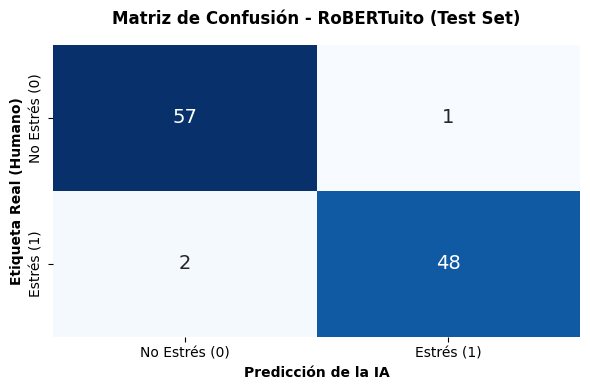


✅ FASE 5 COMPLETADA. Gráfico de alta calidad exportado a:
/content/drive/MyDrive/Proyecto_NLP/matriz_confusion_final.png


In [6]:
# ==============================================================================
# BLOQUE 4 - FASE 5: EVALUACIÓN SOBRE LA BÓVEDA CIEGA (TEST SET)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*60)
print("INICIANDO FASE 5: EVALUACIÓN FINAL SOBRE DATOS NO VISTOS")
print("="*60 + "\n")

# 1. Inferencia sobre el conjunto de testeo (15%)
print("Ejecutando inferencia neuronal sobre la bóveda de testeo...\n")
predicciones_test = entrenador.predict(ds_test_tokenizado)

# 2. Extracción de etiquetas reales vs. predicciones de la máquina
# Las predicciones vienen en decimales, usamos argmax para pasarlas a enteros (0 o 1)
etiquetas_predichas = np.argmax(predicciones_test.predictions, axis=1)
etiquetas_reales = predicciones_test.label_ids

# 3. Reporte de Clasificación Exacto
print("-" * 50)
print("REPORTE DE CLASIFICACIÓN FINAL:")
print("-" * 50)
reporte = classification_report(
    etiquetas_reales,
    etiquetas_predichas,
    target_names=["0: No Estrés", "1: Estrés"],
    digits=4 # Muestra 4 decimales para mayor precisión académica
)
print(reporte)

# 4. Generación de la Matriz de Confusión Visual
print("\nGenerando Matriz de Confusión...")
matriz = confusion_matrix(etiquetas_reales, etiquetas_predichas)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Estrés (0)", "Estrés (1)"],
            yticklabels=["No Estrés (0)", "Estrés (1)"],
            cbar=False, annot_kws={"size": 14})

plt.title('Matriz de Confusión - RoBERTuito (Test Set)', pad=15, fontweight='bold')
plt.ylabel('Etiqueta Real (Humano)', fontweight='bold')
plt.xlabel('Predicción de la IA', fontweight='bold')
plt.tight_layout()

# 5. Exportación de la gráfica a tu Google Drive
ruta_imagen = "/content/drive/MyDrive/Proyecto_NLP/matriz_confusion_final.png"
plt.savefig(ruta_imagen, dpi=300)
plt.show()

print("\n" + "="*60)
print(f"✅ FASE 5 COMPLETADA. Gráfico de alta calidad exportado a:\n{ruta_imagen}")
print("="*60)